# Healthcare AI - Predictive Model Training
This notebook follows a structured Data Science workflow to train a Random Forest Classifier for disease prediction.

## 1. Import Basic Packages
Importing data manipulation, visualization, and machine learning libraries.

In [8]:
# Import basic packages for data manipulation and math operations
import pandas as pd
import numpy as np

# Import packages for Exploratory Data Analysis (EDA) and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning packages from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import joblib for saving the trained model
import joblib

# Set seaborn plotting style for better visuals
sns.set_theme(style="whitegrid")


## 2. Import Dataset
Load the training dataset and handle any trailing empty columns.

In [9]:
# Load the training dataset from the data folder
train_df = pd.read_csv('data/Training.csv')

# The dataset often has an empty trailing column named 'Unnamed: 133'. We must drop it.
if 'Unnamed: 133' in train_df.columns:
    train_df = train_df.drop('Unnamed: 133', axis=1)

# Display the first 5 rows to verify successful loading
train_df.head()


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## 3. Exploratory Data Analysis (EDA)
Analyze the shape, data types, and distribution of the target variable.

In [10]:
# Print the shape of the dataset (rows, columns)
print(f"Dataset Shape: {train_df.shape[0]} rows and {train_df.shape[1]} columns")

# Check for any missing (null) values in the dataset
missing_values = train_df.isnull().sum().sum()
print(f"Total missing values: {missing_values}")

# Display basic information about the dataframe columns and data types
train_df.info()


Dataset Shape: 4920 rows and 133 columns
Total missing values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB


C:\Users\Varun\AppData\Local\Temp\ipykernel_28536\1435804055.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='prognosis', data=train_df, order=train_df['prognosis'].value_counts().index, palette='viridis')


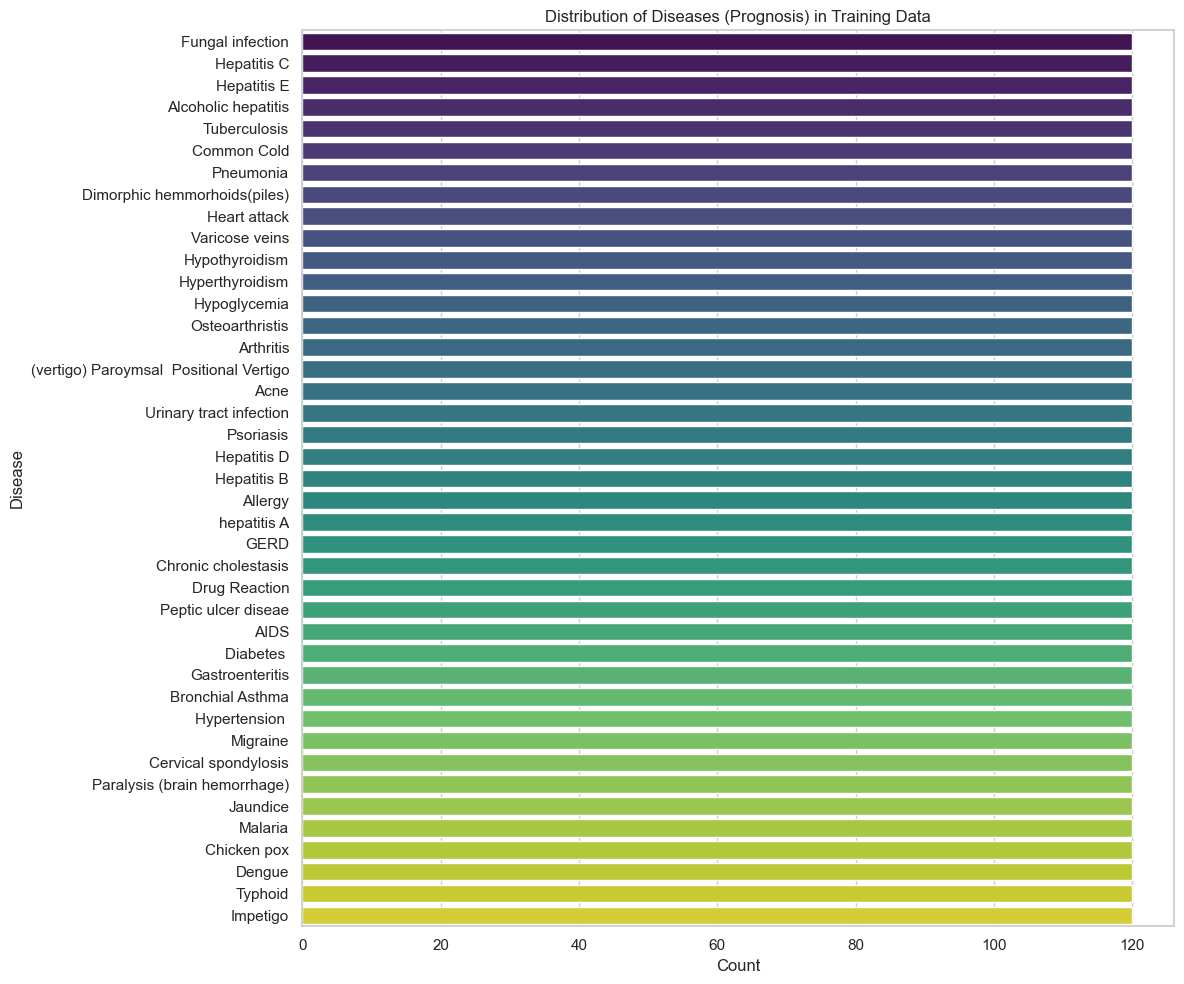

In [11]:
# Visualize the distribution of the target variable ('prognosis')
# This helps us understand if the dataset is balanced across all diseases
plt.figure(figsize=(12, 10))
sns.countplot(y='prognosis', data=train_df, order=train_df['prognosis'].value_counts().index, palette='viridis')
plt.title('Distribution of Diseases (Prognosis) in Training Data')
plt.xlabel('Count')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing
Separate the features (X) from the target (y) and encode the string labels into numbers.

In [12]:
# Separate the input features (symptoms) from the target (disease)
# X contains all columns EXCEPT 'prognosis'
X_train = train_df.drop('prognosis', axis=1)

# y contains ONLY the 'prognosis' column
y_train_raw = train_df['prognosis']

# Machine Learning models require numeric labels. 
# We use LabelEncoder to convert disease names (strings) into integer IDs (0 to 40)
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)

print(f"Encoded {len(le.classes_)} unique diseases.")
print("Sample mappings:", dict(zip(le.classes_[:3], le.transform(le.classes_[:3]))))


Encoded 41 unique diseases.
Sample mappings: {'(vertigo) Paroymsal  Positional Vertigo': 0, 'AIDS': 1, 'Acne': 2}


## 5. Model Training
Train a Random Forest Classifier on the preprocessed training dataset.

In [13]:
# Initialize the Random Forest Classifier
# n_estimators=100 means we are using 100 decision trees in our forest
# random_state=42 ensures our results are reproducible
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train (fit) the model using the training features and encoded labels
print("Training the Random Forest model...")
model.fit(X_train, y_train)
print("Model training complete!")


Training the Random Forest model...
Model training complete!


## 6. Model Evaluation
Load the Testing.csv dataset, preprocess it, and evaluate the model's accuracy.

In [14]:
# Load the testing dataset
test_df = pd.read_csv('data/Testing.csv')

# Drop the empty trailing column if it exists in the test set
if 'Unnamed: 133' in test_df.columns:
    test_df = test_df.drop('Unnamed: 133', axis=1)

# Separate features and target for the test set
X_test = test_df.drop('prognosis', axis=1)
y_test_raw = test_df['prognosis']

# Encode the test labels using the SAME LabelEncoder we fit on the training data
y_test = le.transform(y_test_raw)

# Generate predictions using our trained model
y_pred = model.predict(X_test)

# Calculate and print the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%\n")

# Print a detailed classification report (Precision, Recall, F1-Score for each class)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Test Accuracy: 97.62%

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00  

c:\Users\Varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\Varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\Varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\Varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_targ

c:\Users\Varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\Varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\Varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)
c:\Users\Varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)


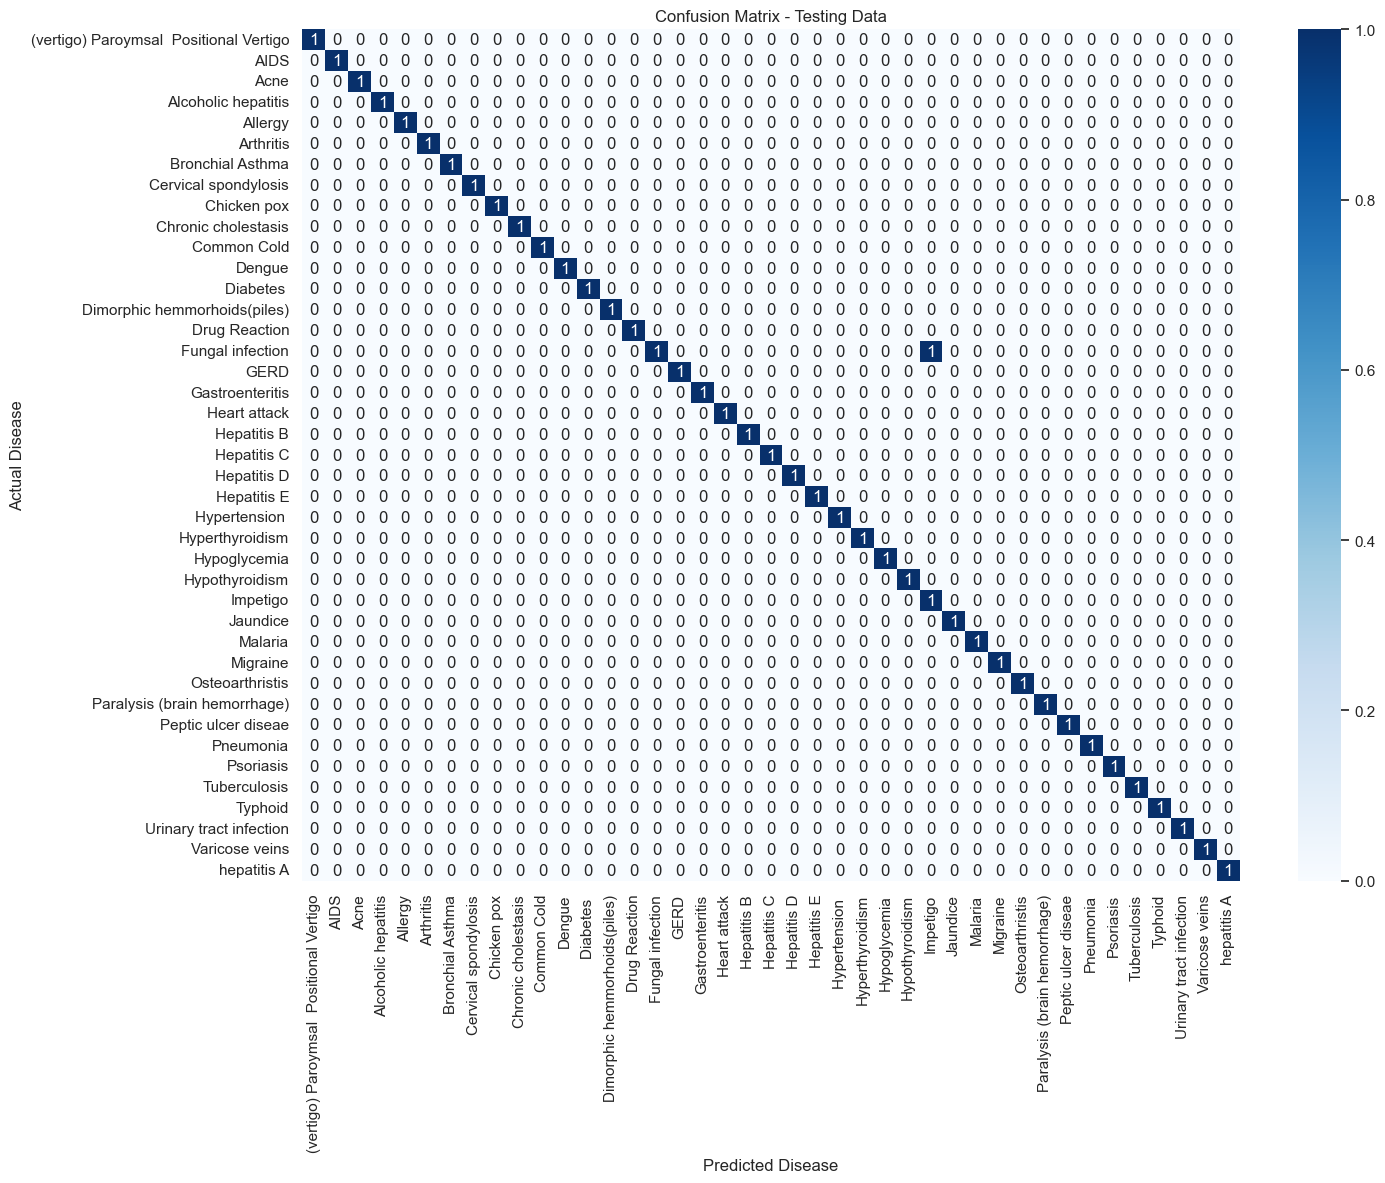

In [15]:
# Visualize the model's performance using a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 12))
# Draw a heatmap of the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Testing Data')
plt.xlabel('Predicted Disease')
plt.ylabel('Actual Disease')
plt.tight_layout()
plt.show()


## 7. Save the Model
Save the trained model and LabelEncoder so they can be loaded by the FastAPI backend.

In [16]:
# We bundle the model and the label encoder into a dictionary 
# so we can easily load both in our backend API
model_data = {
    'model': model,
    'label_encoder': le,
    'features': list(X_train.columns) # Save feature names to ensure order matches during inference
}

# Save the dictionary to a .pkl file using joblib
joblib.dump(model_data, 'trained_model.pkl')
print("Model successfully saved as 'trained_model.pkl'")


Model successfully saved as 'trained_model.pkl'
